# Constitutional-Aware Ayurvedic Disease Prediction
## Machine Learning Training Notebook


## Step 1: Install Required Libraries

Run this cell first to install all dependencies.

In [1]:
# Install required packages
%pip install pandas numpy scikit-learn openpyxl matplotlib seaborn joblib --quiet

print(" All libraries installed successfully!")

Note: you may need to restart the kernel to use updated packages.
 All libraries installed successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import joblib

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 3: Load Dataset



In [2]:
DATASET_FILE = 'ayurvedic_dataset.xlsx'


print("Loading datasets...")
symptom_disease = pd.read_excel(DATASET_FILE, sheet_name='Symptom-Disease Mapping')
prakriti_questions = pd.read_excel(DATASET_FILE, sheet_name='Prakriti Questions')
prakriti_responses = pd.read_excel(DATASET_FILE, sheet_name='Prakriti Sample Responses')
patient_records = pd.read_excel(DATASET_FILE, sheet_name='Patient Symptom Records')
ner_data = pd.read_excel(DATASET_FILE, sheet_name='NER Training Data')

print(f"\n Datasets loaded successfully!\n")
print(f"Symptom-Disease Mappings: {len(symptom_disease)} records")
print(f"Prakriti Questions: {len(prakriti_questions)} questions")
print(f"Prakriti Responses: {len(prakriti_responses)} samples")
print(f"Patient Records: {len(patient_records)} records")
print(f"NER Training Data: {len(ner_data)} entities")

Loading datasets...

 Datasets loaded successfully!

Symptom-Disease Mappings: 60 records
Prakriti Questions: 15 questions
Prakriti Responses: 150 samples
Patient Records: 2992 records
NER Training Data: 47 entities


## Step 4: Explore the Data

In [3]:
print("Patient Records Sample:")
display(patient_records.head())

print("\n Dataset Info:")
print(patient_records.info())

Patient Records Sample:


,Patient_ID,Age,Gender,Prakriti,Vata_Score,Pitta_Score,Kapha_Score,Symptom,Severity,Duration_Days,Disease,Hospital,Date_Recorded
0,P0001,35,Female,Kapha,0.21,0.10,0.69,Sweet taste in mouth,Mild,26,Gastritis,Colombo Ayurveda Clinic,2024-06-26
1,P0001,35,Female,Kapha,0.21,0.10,0.69,Excessive salivation,Moderate,115,Gastritis,Nawinna Ayurveda Hospital,2024-06-24
2,P0002,70,Female,Pitta,0.20,0.74,0.06,Sour belching,Severe,118,Gastritis,Nawinna Ayurveda Hospital,2024-08-05
3,P0002,70,Female,Pitta,0.20,0.74,0.06,Nausea,Mild,66,Gastritis,Colombo Ayurveda Clinic,2024-02-06
4,P0003,52,Male,Pitta-Kapha,0.21,0.35,0.44,Nausea,Severe,60,Gastritis,Nawinna Ayurveda Hospital,2024-03-23



 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2992 entries, 0 to 2991
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Patient_ID     2992 non-null   object 
 1   Age            2992 non-null   int64  
 2   Gender         2992 non-null   object 
 3   Prakriti       2992 non-null   object 
 4   Vata_Score     2992 non-null   float64
 5   Pitta_Score    2992 non-null   float64
 6   Kapha_Score    2992 non-null   float64
 7   Symptom        2992 non-null   object 
 8   Severity       2992 non-null   object 
 9   Duration_Days  2992 non-null   int64  
 10  Disease        2992 non-null   object 
 11  Hospital       2992 non-null   object 
 12  Date_Recorded  2992 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 304.0+ KB
None


In [4]:
patient_records = patient_records.drop('Hospital', axis=1)

In [5]:
display(patient_records.head())

,Patient_ID,Age,Gender,Prakriti,Vata_Score,Pitta_Score,Kapha_Score,Symptom,Severity,Duration_Days,Disease,Date_Recorded
0,P0001,35,Female,Kapha,0.21,0.10,0.69,Sweet taste in mouth,Mild,26,Gastritis,2024-06-26
1,P0001,35,Female,Kapha,0.21,0.10,0.69,Excessive salivation,Moderate,115,Gastritis,2024-06-24
2,P0002,70,Female,Pitta,0.20,0.74,0.06,Sour belching,Severe,118,Gastritis,2024-08-05
3,P0002,70,Female,Pitta,0.20,0.74,0.06,Nausea,Mild,66,Gastritis,2024-02-06
4,P0003,52,Male,Pitta-Kapha,0.21,0.35,0.44,Nausea,Severe,60,Gastritis,2024-03-23


Disease Distribution:
Disease
Diabetes     622
Migraine     605
Arthritis    590
Asthma       588
Gastritis    587
Name: count, dtype: int64


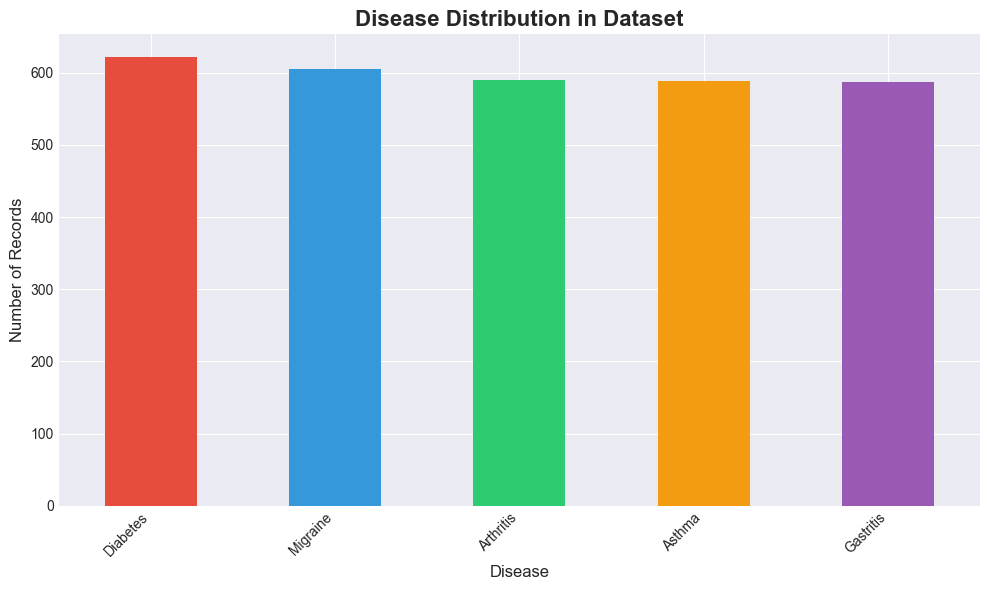

In [6]:
# Disease distribution
print("Disease Distribution:")
disease_counts = patient_records['Disease'].value_counts()
print(disease_counts)

# Visualize
plt.figure(figsize=(10, 6))
disease_counts.plot(kind='bar', color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6'])
plt.title('Disease Distribution in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Prakriti (Constitutional Type) Distribution:
Prakriti
Kapha          538
Pitta          537
Vata           514
Vata-Kapha     495
Vata-Pitta     471
Pitta-Kapha    437
Name: count, dtype: int64


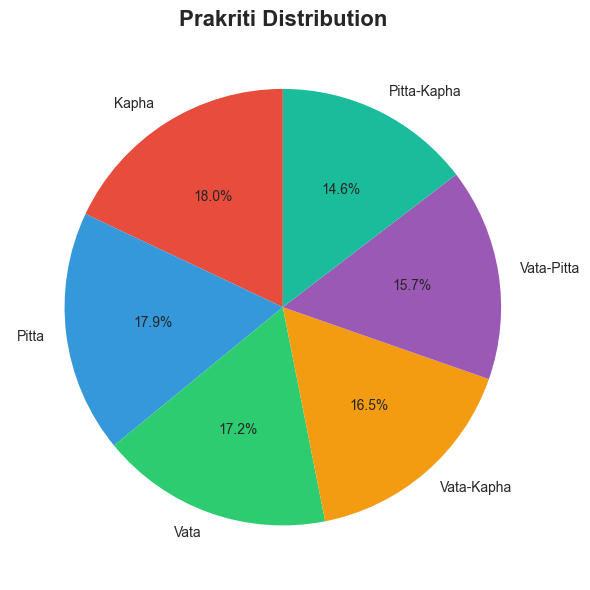

In [7]:
# Prakriti distribution
print("Prakriti (Constitutional Type) Distribution:")
prakriti_counts = patient_records['Prakriti'].value_counts()
print(prakriti_counts)

# Visualize
plt.figure(figsize=(10, 6))
prakriti_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                     colors=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C'])
plt.title('Prakriti Distribution', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Step 5: Data Preprocessing

In [8]:
print("Preprocessing data...\n")

# Make a copy
df = patient_records.copy()

# Check for missing values
print("1. Checking for missing values...")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(f"Warning: {missing.sum()} missing values found")
    print(missing[missing > 0])
else:
    print("No missing values!")

# Initialize encoders
encoders = {}

# Encode categorical variables
print("\n2. Encoding categorical variables...")
categorical_cols = ['Gender', 'Symptom', 'Severity', 'Prakriti']

for col in categorical_cols:
    if col in df.columns:
        encoders[col] = LabelEncoder()
        df[f'{col}_encoded'] = encoders[col].fit_transform(df[col])
        print(f"{col}: {len(encoders[col].classes_)} unique values")

# Encode target variable (Disease)
print("\n3. Encoding target variable (Disease)...")
encoders['Disease'] = LabelEncoder()
df['Disease_encoded'] = encoders['Disease'].fit_transform(df['Disease'])
print(f" Disease: {len(encoders['Disease'].classes_)} classes")
print(f"   Classes: {list(encoders['Disease'].classes_)}")

print("\n Preprocessing complete!")

Preprocessing data...

1. Checking for missing values...
No missing values!

2. Encoding categorical variables...
Gender: 2 unique values
Symptom: 59 unique values
Severity: 3 unique values
Prakriti: 6 unique values

3. Encoding target variable (Disease)...
 Disease: 5 classes
   Classes: ['Arthritis', 'Asthma', 'Diabetes', 'Gastritis', 'Migraine']

 Preprocessing complete!


## Step 6: Feature Engineering


1. **Constitutional-Aware** (with Vata, Pitta, Kapha scores) 
2. **Basic** (symptom-only, no constitutional data) 

In [ ]:
print("Creating feature sets...\n")

# Basic features (symptom-only approach)
basic_features = [
    'Age',
    'Gender_encoded',
    'Symptom_encoded',
    'Severity_encoded',
    'Duration_Days'
]

# Constitutional features (novel approach)
constitutional_features = basic_features + [
    'Vata_Score',
    'Pitta_Score',
    'Kapha_Score',
    'Prakriti_encoded'
]

# NEW: Enhanced constitutional features with imbalance detection
enhanced_constitutional_features = constitutional_features + [
    'Vata_Imbalance',
    'Pitta_Imbalance',
    'Kapha_Imbalance'
]

print("BASIC Features (5):")
for i, feat in enumerate(basic_features, 1):
    print(f"   {i}. {feat}")

print("\n⭐ CONSTITUTIONAL-AWARE Features (9):")
for i, feat in enumerate(constitutional_features, 1):
    marker = "⭐" if feat in ['Vata_Score', 'Pitta_Score', 'Kapha_Score', 'Prakriti_encoded'] else "  "
    print(f"   {marker} {i}. {feat}")

print("\n🌟 ENHANCED CONSTITUTIONAL-AWARE Features (12):")
for i, feat in enumerate(enhanced_constitutional_features, 1):
    if feat in ['Vata_Imbalance', 'Pitta_Imbalance', 'Kapha_Imbalance']:
        marker = "🌟"
    elif feat in ['Vata_Score', 'Pitta_Score', 'Kapha_Score', 'Prakriti_encoded']:
        marker = "⭐"
    else:
        marker = "  "
    print(f"   {marker} {i}. {feat}")

print("\n Feature sets created!")


Creating feature sets...

BASIC Features (5):
   1. Age
   2. Gender_encoded
   3. Symptom_encoded
   4. Severity_encoded
   5. Duration_Days

⭐ CONSTITUTIONAL-AWARE Features (9):
      1. Age
      2. Gender_encoded
      3. Symptom_encoded
      4. Severity_encoded
      5. Duration_Days
   ⭐ 6. Vata_Score
   ⭐ 7. Pitta_Score
   ⭐ 8. Kapha_Score
   ⭐ 9. Prakriti_encoded

🌟 ENHANCED CONSTITUTIONAL-AWARE Features (12):
      1. Age
      2. Gender_encoded
      3. Symptom_encoded
      4. Severity_encoded
      5. Duration_Days
   ⭐ 6. Vata_Score
   ⭐ 7. Pitta_Score
   ⭐ 8. Kapha_Score
   ⭐ 9. Prakriti_encoded
   🌟 10. Vata_Imbalance
   🌟 11. Pitta_Imbalance
   🌟 12. Kapha_Imbalance

 Feature sets created!


## Step 6: Dosha Imbalance Mapping

Map symptoms to their corresponding dosha imbalances based on Ayurvedic texts.

In [ ]:

DOSHA_SYMPTOMS = {
    'vata': [
        'Dry cough', 'Constipation', 'Irregular burning sensation',
        'Joint stiffness in morning', 'Difficulty breathing',
        'Crackling sound in joints', 'Dizziness', 'Difficulty in movement',
        'Dry mouth', 'Weight loss', 'Fatigue', 'Visual disturbances'
    ],
    'pitta': [
        'Intense burning sensation', 'Acid regurgitation',
        'Burning sensation in joints', 'Redness around joints',
        'Fever with joint pain', 'Burning sensation in head',
        'Redness in eyes', 'Nausea with headache', 'Inflammation',
        'Burning sensation while urinating', 'Yellowish urine',
        'Excessive hunger', 'Fever with breathing difficulty',
        'Yellowish sputum'
    ],
    'kapha': [
        'Heavy feeling in stomach', 'Joint swelling', 'Heaviness in joints',
        'Excessive sleep', 'Productive cough', 'White thick sputum',
        'Heaviness in head', 'Heaviness in chest', 'Nasal congestion',
        'Bloating with gas', 'Sweet taste in mouth', 'Loss of appetite',
        'Excessive salivation', 'Coldness in affected area',
        'Reduced flexibility', 'Heaviness in body', 'Throbbing headache',
        'Dull aching pain', 'Chest tightness', 'Wheezing sound',
        'Relief after expectoration'
    ]
}

def calculate_dosha_imbalance(symptom, prakriti):
    """
    Calculate which dosha is imbalanced based on symptom.
    Returns imbalance multipliers (1.5 for affected dosha, 1.0 for others).
    """
    # Find which dosha this symptom belongs to
    affected_dosha = None
    for dosha, symptoms in DOSHA_SYMPTOMS.items():
        if symptom in symptoms:
            affected_dosha = dosha
            break
    
    # If symptom not in mapping, use prakriti dominant dosha
    if affected_dosha is None:
        affected_dosha = prakriti.lower()
    
    # Return imbalance values
    return {
        'vata_imbalance': 1.5 if affected_dosha == 'vata' else 1.0,
        'pitta_imbalance': 1.5 if affected_dosha == 'pitta' else 1.0,
        'kapha_imbalance': 1.5 if affected_dosha == 'kapha' else 1.0,
    }

print("Dosha imbalance calculation function created!")
print(f"   Mapped {sum(len(v) for v in DOSHA_SYMPTOMS.values())} symptoms to doshas")

# Test the function
test_result = calculate_dosha_imbalance('Dry cough', 'Pitta')
print(f"\n Test: 'Dry cough' (Pitta person)")
print(f"   Vata imbalance: {test_result['vata_imbalance']}")
print(f"   Pitta imbalance: {test_result['pitta_imbalance']}")
print(f"   Kapha imbalance: {test_result['kapha_imbalance']}")


Dosha imbalance calculation function created!
   Mapped 47 symptoms to doshas

🧪 Test: 'Dry cough' (Pitta person)
   Vata imbalance: 1.5
   Pitta imbalance: 1.0
   Kapha imbalance: 1.0


In [11]:
print("Adding dosha imbalance features to dataset...")

# Initialize columns
df['Vata_Imbalance'] = 1.0
df['Pitta_Imbalance'] = 1.0
df['Kapha_Imbalance'] = 1.0

# Calculate imbalances for each row
for idx, row in df.iterrows():
    symptom = row['Symptom']
    prakriti = row.get('Prakriti', 'Pitta')  # Default to Pitta if missing
    
    imbalance = calculate_dosha_imbalance(symptom, prakriti)
    
    df.at[idx, 'Vata_Imbalance'] = imbalance['vata_imbalance']
    df.at[idx, 'Pitta_Imbalance'] = imbalance['pitta_imbalance']
    df.at[idx, 'Kapha_Imbalance'] = imbalance['kapha_imbalance']

print(f"Added imbalance features!")
print(f"   Vata imbalanced: {(df['Vata_Imbalance'] == 1.5).sum()} records")
print(f"   Pitta imbalanced: {(df['Pitta_Imbalance'] == 1.5).sum()} records")
print(f"   Kapha imbalanced: {(df['Kapha_Imbalance'] == 1.5).sum()} records")

# Show sample
print("\n Sample data with imbalance features:")
display(df[['Symptom', 'Disease', 'Prakriti', 
            'Vata_Imbalance', 'Pitta_Imbalance', 'Kapha_Imbalance']].head(10))


Adding dosha imbalance features to dataset...
Added imbalance features!
   Vata imbalanced: 757 records
   Pitta imbalanced: 826 records
   Kapha imbalanced: 1150 records

 Sample data with imbalance features:


,Symptom,Disease,Prakriti,Vata_Imbalance,Pitta_Imbalance,Kapha_Imbalance
0,Sweet taste in mouth,Gastritis,Kapha,1.0,1.0,1.5
1,Excessive salivation,Gastritis,Kapha,1.0,1.0,1.5
2,Sour belching,Gastritis,Pitta,1.0,1.5,1.0
3,Nausea,Gastritis,Pitta,1.0,1.5,1.0
4,Nausea,Gastritis,Pitta-Kapha,1.0,1.0,1.0
5,Acid regurgitation,Gastritis,Pitta-Kapha,1.0,1.5,1.0
6,Sweet taste in mouth,Gastritis,Pitta-Kapha,1.0,1.0,1.5
7,Intense burning sensation,Gastritis,Pitta-Kapha,1.0,1.5,1.0
8,Loss of appetite,Gastritis,Vata-Kapha,1.0,1.0,1.5
9,Excessive salivation,Gastritis,Vata-Kapha,1.0,1.0,1.5


## Step 7: Prepare Data for Training

In [12]:
# Prepare constitutional-aware dataset
X_const = df[constitutional_features]

# Prepare basic dataset
X_basic = df[basic_features]

X_enhanced = df[enhanced_constitutional_features]

# Target variable
y = df['Disease_encoded']

print(f" Dataset shapes:")
print(f"   Basic model: {X_basic.shape} (5 features)")
print(f"   Constitutional model: {X_const.shape} (9 features)")
print(f"   Enhanced model: {X_enhanced.shape} (12 features) 🌟")
print(f"   Target: {y.shape}")

print(f"\n Data prepared for all three models!")


 Dataset shapes:
   Basic model: (2992, 5) (5 features)
   Constitutional model: (2992, 9) (9 features)
   Enhanced model: (2992, 12) (12 features) 🌟
   Target: (2992,)

 Data prepared for all three models!


In [13]:
# Split data (80% train, 20% test)
print(" Splitting data...\n")

# Constitutional-aware split
X_train_const, X_test_const, y_train, y_test = train_test_split(
    X_const, y, test_size=0.2, random_state=42, stratify=y
)

# Basic split
X_train_basic, X_test_basic, _, _ = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Constitutional-Aware:")
print(f"  Training set: {len(X_train_const)} samples")
print(f"  Test set: {len(X_test_const)} samples")

print(f"\nBasic (Symptom-Only):")
print(f"  Training set: {len(X_train_basic)} samples")
print(f"  Test set: {len(X_test_basic)} samples")

print(f"\n Data split complete!")

 Splitting data...

Constitutional-Aware:
  Training set: 2393 samples
  Test set: 599 samples

Basic (Symptom-Only):
  Training set: 2393 samples
  Test set: 599 samples

 Data split complete!


## Step 8: Train Models - CONSTITUTIONAL-AWARE



In [14]:
print("="*70)
print(" TRAINING CONSTITUTIONAL-AWARE MODELS")
print("="*70)

models_const = {}

 TRAINING CONSTITUTIONAL-AWARE MODELS


In [15]:
# Model 1: Random Forest
print("\n Training Random Forest...")

rf_const = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_const.fit(X_train_const, y_train)
models_const['Random Forest'] = rf_const

# Evaluate
train_acc = rf_const.score(X_train_const, y_train)
test_acc = rf_const.score(X_test_const, y_test)
cv_scores = cross_val_score(rf_const, X_train_const, y_train, cv=5)

print(f" Training accuracy: {train_acc:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': constitutional_features,
    'importance': rf_const.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Top 5 most important features:")
for idx, row in feature_importance.head().iterrows():
    print(f"    {row['feature']}: {row['importance']:.4f}")


 Training Random Forest...
 Training accuracy: 0.9490
  Test accuracy: 0.8247
  Cross-validation: 0.7906 (+/- 0.0105)

  Top 5 most important features:
    Symptom_encoded: 0.5277
    Kapha_Score: 0.0945
    Age: 0.0923
    Pitta_Score: 0.0877
    Vata_Score: 0.0875


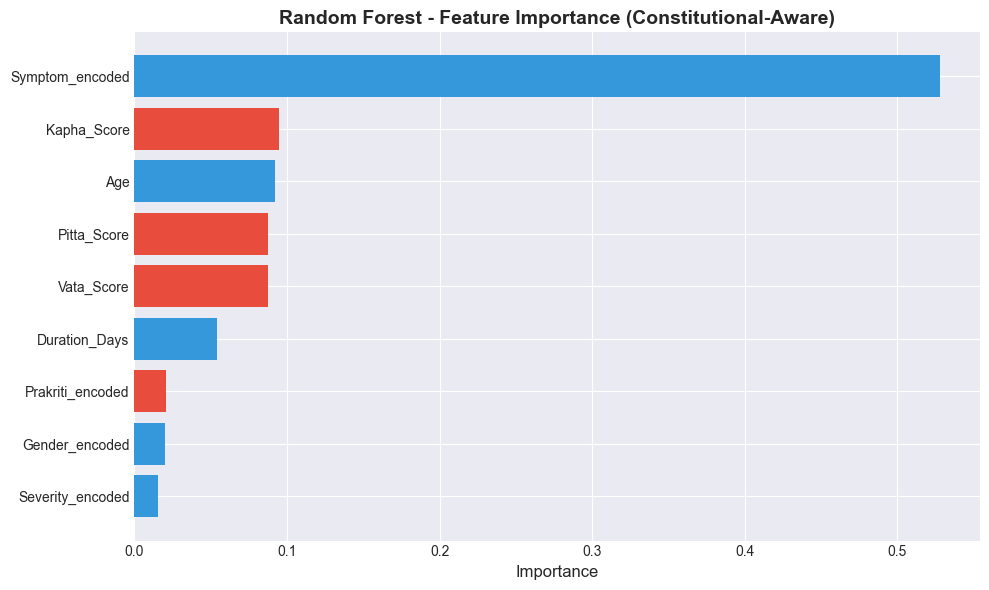

In [16]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], 
         color=['#E74C3C' if 'Score' in f or 'Prakriti' in f else '#3498DB' 
                for f in feature_importance['feature']])
plt.xlabel('Importance', fontsize=12)
plt.title('Random Forest - Feature Importance (Constitutional-Aware)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
# Model 2: SVM
print("\n  Training SVM...")

# Scale features for SVM
scaler_svm = StandardScaler()
X_train_const_scaled = scaler_svm.fit_transform(X_train_const)
X_test_const_scaled = scaler_svm.transform(X_test_const)

svm_const = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_const.fit(X_train_const_scaled, y_train)
models_const['SVM'] = (svm_const, scaler_svm)

# Evaluate
train_acc = svm_const.score(X_train_const_scaled, y_train)
test_acc = svm_const.score(X_test_const_scaled, y_test)
cv_scores = cross_val_score(svm_const, X_train_const_scaled, y_train, cv=5)

print(f"  Training accuracy: {train_acc:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


  Training SVM...
  Training accuracy: 0.4542
  Test accuracy: 0.3406
  Cross-validation: 0.3527 (+/- 0.0187)


In [18]:
# Model 3: Neural Network
print("\n Training Neural Network...")

# Scale features for NN
scaler_nn = StandardScaler()
X_train_const_scaled_nn = scaler_nn.fit_transform(X_train_const)
X_test_const_scaled_nn = scaler_nn.transform(X_test_const)

nn_const = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
nn_const.fit(X_train_const_scaled_nn, y_train)
models_const['Neural Network'] = (nn_const, scaler_nn)

# Evaluate
train_acc = nn_const.score(X_train_const_scaled_nn, y_train)
test_acc = nn_const.score(X_test_const_scaled_nn, y_test)
cv_scores = cross_val_score(nn_const, X_train_const_scaled_nn, y_train, cv=5)

print(f"  Training accuracy: {train_acc:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Cross-validation: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  Iterations: {nn_const.n_iter_}")

print("\n All constitutional-aware models trained!")


 Training Neural Network...
  Training accuracy: 0.8525
  Test accuracy: 0.4725
  Cross-validation: 0.4296 (+/- 0.0267)
  Iterations: 500

 All constitutional-aware models trained!


## Step 9: Train Models - BASIC (Symptom-Only)

Training same 3 algorithms WITHOUT constitutional features for comparison

In [19]:
print("="*70)
print(" TRAINING BASIC (SYMPTOM-ONLY) MODELS")
print("="*70)

models_basic = {}

 TRAINING BASIC (SYMPTOM-ONLY) MODELS


In [20]:
# Model 1: Random Forest (Basic)
print("\n Training Random Forest (Basic)...")

rf_basic = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf_basic.fit(X_train_basic, y_train)
models_basic['Random Forest'] = rf_basic

test_acc = rf_basic.score(X_test_basic, y_test)
print(f"  Test accuracy: {test_acc:.4f}")


 Training Random Forest (Basic)...
  Test accuracy: 0.6544


In [21]:
# Model 2: SVM (Basic)
print("\n  Training SVM (Basic)...")

scaler_svm_basic = StandardScaler()
X_train_basic_scaled = scaler_svm_basic.fit_transform(X_train_basic)
X_test_basic_scaled = scaler_svm_basic.transform(X_test_basic)

svm_basic = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_basic.fit(X_train_basic_scaled, y_train)
models_basic['SVM'] = (svm_basic, scaler_svm_basic)

test_acc = svm_basic.score(X_test_basic_scaled, y_test)
print(f"  Test accuracy: {test_acc:.4f}")


  Training SVM (Basic)...
  Test accuracy: 0.3255


In [22]:
# Model 3: Neural Network (Basic)
print("\n Training Neural Network (Basic)...")

scaler_nn_basic = StandardScaler()
X_train_basic_scaled_nn = scaler_nn_basic.fit_transform(X_train_basic)
X_test_basic_scaled_nn = scaler_nn_basic.transform(X_test_basic)

nn_basic = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)
nn_basic.fit(X_train_basic_scaled_nn, y_train)
models_basic['Neural Network'] = (nn_basic, scaler_nn_basic)

test_acc = nn_basic.score(X_test_basic_scaled_nn, y_test)
print(f"  Test accuracy: {test_acc:.4f}")

print("\n All basic models trained!")


 Training Neural Network (Basic)...
  Test accuracy: 0.4124

 All basic models trained!


## Step 10: Evaluate All Models

In [23]:
# Function to evaluate model
def evaluate_model(model, X_test, y_test, is_scaled=False):
    if is_scaled:
        model, scaler = model
        X_test = scaler.transform(X_test)
    
    y_pred = model.predict(X_test)
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

In [24]:
# Evaluate Constitutional-Aware models
print("Evaluating CONSTITUTIONAL-AWARE models...\n")

results_const = {}
for name, model in models_const.items():
    is_scaled = name != 'Random Forest'
    results_const[name] = evaluate_model(model, X_test_const, y_test, is_scaled)
    
    print(f"{name}:")
    print(f"  Accuracy:  {results_const[name]['accuracy']:.4f}")
    print(f"  Precision: {results_const[name]['precision']:.4f}")
    print(f"  Recall:    {results_const[name]['recall']:.4f}")
    print(f"  F1-Score:  {results_const[name]['f1_score']:.4f}")
    print()

Evaluating CONSTITUTIONAL-AWARE models...

Random Forest:
  Accuracy:  0.8247
  Precision: 0.8333
  Recall:    0.8247
  F1-Score:  0.8238

SVM:
  Accuracy:  0.3406
  Precision: 0.3334
  Recall:    0.3406
  F1-Score:  0.3297

Neural Network:
  Accuracy:  0.4725
  Precision: 0.4729
  Recall:    0.4725
  F1-Score:  0.4722



In [25]:
# Evaluate Basic models
print(" Evaluating BASIC (SYMPTOM-ONLY) models...\n")

results_basic = {}
for name, model in models_basic.items():
    is_scaled = name != 'Random Forest'
    results_basic[name] = evaluate_model(model, X_test_basic, y_test, is_scaled)
    
    print(f"{name}:")
    print(f"  Accuracy:  {results_basic[name]['accuracy']:.4f}")
    print(f"  Precision: {results_basic[name]['precision']:.4f}")
    print(f"  Recall:    {results_basic[name]['recall']:.4f}")
    print(f"  F1-Score:  {results_basic[name]['f1_score']:.4f}")
    print()

 Evaluating BASIC (SYMPTOM-ONLY) models...

Random Forest:
  Accuracy:  0.6544
  Precision: 0.6665
  Recall:    0.6544
  F1-Score:  0.6532

SVM:
  Accuracy:  0.3255
  Precision: 0.3334
  Recall:    0.3255
  F1-Score:  0.3247

Neural Network:
  Accuracy:  0.4124
  Precision: 0.4124
  Recall:    0.4124
  F1-Score:  0.4113



## Step 11: Compare Constitutional-Aware vs Basic

**This is the KEY FINDING for your research!**

In [26]:
# Create comparison DataFrame
comparison_const = pd.DataFrame(results_const).T
comparison_basic = pd.DataFrame(results_basic).T

print("="*70)
print(" CONSTITUTIONAL-AWARE MODEL RESULTS")
print("="*70)
print(comparison_const.round(4))

print("\n" + "="*70)
print(" BASIC (SYMPTOM-ONLY) MODEL RESULTS")
print("="*70)
print(comparison_basic.round(4))

# Find best models
best_const = comparison_const['f1_score'].idxmax()
best_basic = comparison_basic['f1_score'].idxmax()

print("\n" + "="*70)
print(" BEST MODELS")
print("="*70)
print(f" Constitutional-Aware: {best_const} (F1: {comparison_const.loc[best_const, 'f1_score']:.4f})")
print(f" Basic (Symptom-Only): {best_basic} (F1: {comparison_basic.loc[best_basic, 'f1_score']:.4f})")

 CONSTITUTIONAL-AWARE MODEL RESULTS
                accuracy  precision  recall  f1_score
Random Forest     0.8247     0.8333  0.8247    0.8238
SVM               0.3406     0.3334  0.3406    0.3297
Neural Network    0.4725     0.4729  0.4725    0.4722

 BASIC (SYMPTOM-ONLY) MODEL RESULTS
                accuracy  precision  recall  f1_score
Random Forest     0.6544     0.6665  0.6544    0.6532
SVM               0.3255     0.3334  0.3255    0.3247
Neural Network    0.4124     0.4124  0.4124    0.4113

 BEST MODELS
 Constitutional-Aware: Random Forest (F1: 0.8238)
 Basic (Symptom-Only): Random Forest (F1: 0.6532)


In [27]:
# Calculate improvement
improvement_data = []
for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
    const_val = comparison_const.loc[best_const, metric]
    basic_val = comparison_basic.loc[best_basic, metric]
    improvement = ((const_val - basic_val) / basic_val) * 100
    
    improvement_data.append({
        'Metric': metric.replace('_', ' ').title(),
        'Constitutional': const_val,
        'Basic': basic_val,
        'Improvement (%)': improvement
    })

improvement_df = pd.DataFrame(improvement_data)

print("\n" + "="*70)
print("  IMPROVEMENT ANALYSIS")
print("="*70)
print(improvement_df.to_string(index=False))

avg_improvement = improvement_df['Improvement (%)'].mean()
print(f"\n Average Improvement: {avg_improvement:.2f}%")
print(f"\n Constitutional awareness improves predictions by ~{avg_improvement:.1f}%!")


  IMPROVEMENT ANALYSIS
   Metric  Constitutional    Basic  Improvement (%)
 Accuracy        0.824708 0.654424        26.020408
Precision        0.833296 0.666500        25.025540
   Recall        0.824708 0.654424        26.020408
 F1 Score        0.823803 0.653173        26.123237

 Average Improvement: 25.80%

 Constitutional awareness improves predictions by ~25.8%!


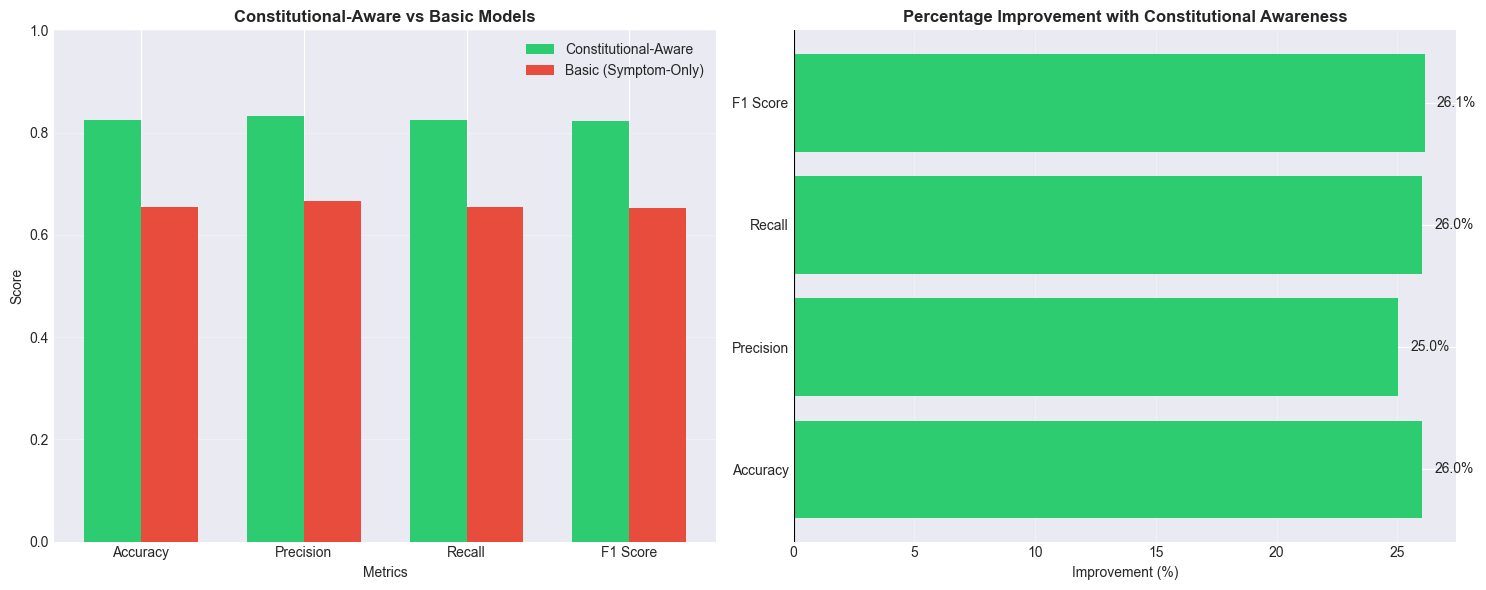


 Constitutional awareness clearly improves performance!


In [28]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Constitutional vs Basic
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
const_vals = [comparison_const.loc[best_const, m] for m in metrics]
basic_vals = [comparison_basic.loc[best_basic, m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, const_vals, width, label='Constitutional-Aware', color='#2ECC71')
axes[0].bar(x + width/2, basic_vals, width, label='Basic (Symptom-Only)', color='#E74C3C')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Constitutional-Aware vs Basic Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('_', ' ').title() for m in metrics])
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Improvement percentage
improvements = improvement_df['Improvement (%)'].values
colors = ['#2ECC71' if imp > 0 else '#E74C3C' for imp in improvements]

axes[1].barh(improvement_df['Metric'], improvements, color=colors)
axes[1].set_xlabel('Improvement (%)')
axes[1].set_title('Percentage Improvement with Constitutional Awareness', fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(improvements):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

print("\n Constitutional awareness clearly improves performance!")

## Step 12: Confusion Matrix (Best Model)

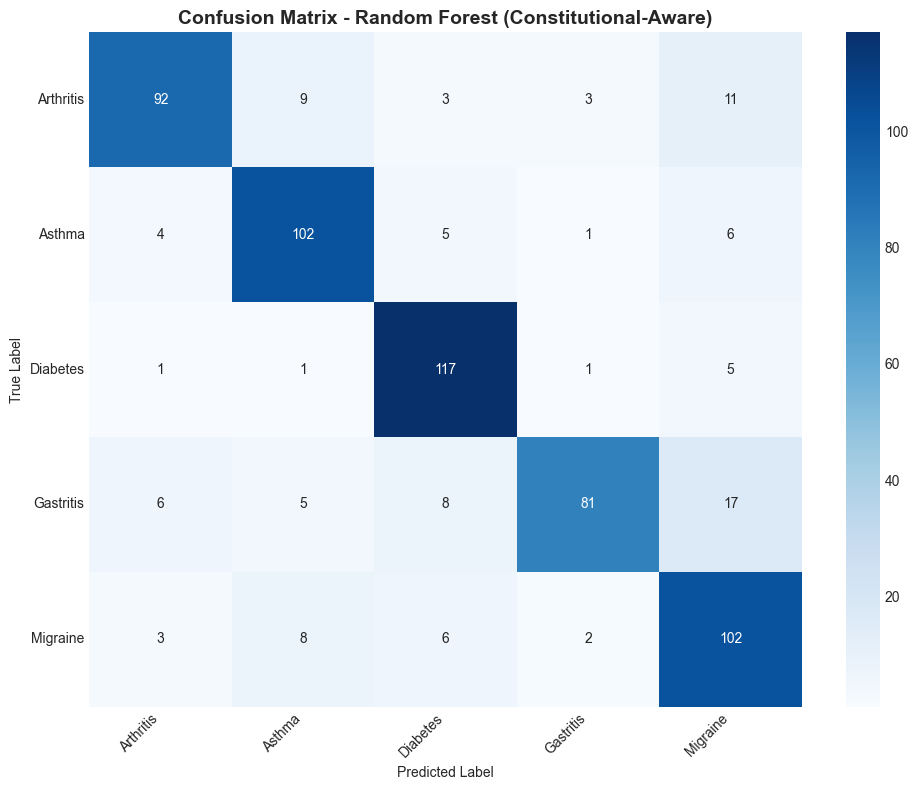

In [29]:
# Get predictions from best constitutional model
best_model = models_const[best_const]

if best_const == 'Random Forest':
    y_pred = best_model.predict(X_test_const)
else:
    model, scaler = best_model
    y_pred = model.predict(scaler.transform(X_test_const))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
disease_names = encoders['Disease'].classes_

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=disease_names, yticklabels=disease_names)
plt.title(f'Confusion Matrix - {best_const} (Constitutional-Aware)', 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 13: Classification Report

In [30]:
print("="*70)
print(f" CLASSIFICATION REPORT: {best_const} (Constitutional-Aware)")
print("="*70)

print(classification_report(y_test, y_pred, target_names=disease_names, zero_division=0))

 CLASSIFICATION REPORT: Random Forest (Constitutional-Aware)
              precision    recall  f1-score   support

   Arthritis       0.87      0.78      0.82       118
      Asthma       0.82      0.86      0.84       118
    Diabetes       0.84      0.94      0.89       125
   Gastritis       0.92      0.69      0.79       117
    Migraine       0.72      0.84      0.78       121

    accuracy                           0.82       599
   macro avg       0.83      0.82      0.82       599
weighted avg       0.83      0.82      0.82       599



## Step 14: Save Best Model

In [35]:
import os

# Create models directory
os.makedirs('models', exist_ok=True)

print("💾 Saving enhanced model and metadata...\n")

# Save enhanced model
joblib.dump(model_enhanced, 'models/best_ayurvedic_model.pkl')
print("✅ Saved: models/best_ayurvedic_model.pkl")

# Save encoders
joblib.dump(encoders, 'models/encoders.pkl')
print("✅ Saved: models/encoders.pkl")

# Save enhanced feature list (12 features)
joblib.dump(enhanced_constitutional_features, 'models/features.pkl')
print("✅ Saved: models/features.pkl")

# No scaler needed for Random Forest
print("ℹ️  Scaler: Not needed (Random Forest)")

print("\n" + "=" * 70)
print("🌟 ENHANCED MODEL PACKAGE SAVED SUCCESSFULLY!")
print("=" * 70)
print(f"\nFeatures in saved model: {len(enhanced_constitutional_features)}")
print("\nFeature list:")
for i, feat in enumerate(enhanced_constitutional_features, 1):
    if 'Imbalance' in feat:
        marker = "🌟"
    elif feat in ['Vata_Score', 'Pitta_Score', 'Kapha_Score', 'Prakriti_encoded']:
        marker = "⭐"
    else:
        marker = "  "
    print(f"   {marker} {i}. {feat}")

print("\n📦 Files ready for deployment:")
print("   📁 models/")
print("      ├── best_ayurvedic_model.pkl")
print("      ├── encoders.pkl")
print("      └── features.pkl (12 features)")


💾 Saving enhanced model and metadata...

✅ Saved: models/best_ayurvedic_model.pkl
✅ Saved: models/encoders.pkl
✅ Saved: models/features.pkl
ℹ️  Scaler: Not needed (Random Forest)

🌟 ENHANCED MODEL PACKAGE SAVED SUCCESSFULLY!

Features in saved model: 12

Feature list:
      1. Age
      2. Gender_encoded
      3. Symptom_encoded
      4. Severity_encoded
      5. Duration_Days
   ⭐ 6. Vata_Score
   ⭐ 7. Pitta_Score
   ⭐ 8. Kapha_Score
   ⭐ 9. Prakriti_encoded
   🌟 10. Vata_Imbalance
   🌟 11. Pitta_Imbalance
   🌟 12. Kapha_Imbalance

📦 Files ready for deployment:
   📁 models/
      ├── best_ayurvedic_model.pkl
      ├── encoders.pkl
      └── features.pkl (12 features)


## Step 7: Train Enhanced Constitutional-Aware Model

Train the model with dosha imbalance features (12 features total).

In [32]:
# ============================================================
# TRAIN ENHANCED CONSTITUTIONAL-AWARE MODEL
# ============================================================

print("Training Enhanced Constitutional-Aware Model...")
print("=" * 60)

# Split data
X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train_enh.shape}")
print(f"Test set: {X_test_enh.shape}")

# Train Random Forest
model_enhanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

print("\n🌟 Training enhanced model with 12 features...")
model_enhanced.fit(X_train_enh, y_train_enh)

# Evaluate
y_pred_enh = model_enhanced.predict(X_test_enh)
accuracy_enh = accuracy_score(y_test_enh, y_pred_enh)

print(f"\n✅ Enhanced Model Accuracy: {accuracy_enh:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test_enh, y_pred_enh, 
                          target_names=encoders['Disease'].classes_,
                          zero_division=0))

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': enhanced_constitutional_features,
    'importance': model_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\n🌟 Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Highlight new imbalance features
print("\n🔍 Imbalance Feature Importance:")
imbalance_features = feature_importance[
    feature_importance['feature'].str.contains('Imbalance')
]
print(imbalance_features.to_string(index=False))

print("\n✅ Enhanced model training complete!")


Training Enhanced Constitutional-Aware Model...
Training set: (2393, 12)
Test set: (599, 12)

🌟 Training enhanced model with 12 features...

✅ Enhanced Model Accuracy: 0.9048

📊 Classification Report:
              precision    recall  f1-score   support

   Arthritis       0.88      0.90      0.89       118
      Asthma       0.91      0.92      0.92       118
    Diabetes       0.94      0.94      0.94       125
   Gastritis       0.94      0.86      0.90       117
    Migraine       0.87      0.90      0.89       121

    accuracy                           0.90       599
   macro avg       0.91      0.90      0.90       599
weighted avg       0.91      0.90      0.90       599


🌟 Top 10 Most Important Features:
         feature  importance
 Symptom_encoded    0.408121
             Age    0.103161
      Vata_Score    0.099159
     Kapha_Score    0.098888
     Pitta_Score    0.096435
   Duration_Days    0.077814
Severity_encoded    0.027834
  Gender_encoded    0.023605
Prakriti_encod

In [33]:
# ============================================================
# COMPARE ALL THREE MODELS
# ============================================================

from sklearn.model_selection import cross_val_score

print("=" * 70)
print("📊 MODEL COMPARISON - 5-FOLD CROSS VALIDATION")
print("=" * 70)

models_to_compare = {
    'Basic (5 features)': X_basic,
    'Constitutional (9 features)': X_const,
    'Enhanced (12 features) ⭐': X_enhanced
}

results = {}
for name, X_data in models_to_compare.items():
    rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=20)
    scores = cross_val_score(rf, X_data, y, cv=5, scoring='accuracy')
    
    results[name] = {
        'mean': scores.mean(),
        'std': scores.std(),
    }
    
    print(f"\n{name}:")
    print(f"   Accuracy: {scores.mean():.4f} (± {scores.std():.4f})")

# Show improvement
basic_acc = results['Basic (5 features)']['mean']
const_acc = results['Constitutional (9 features)']['mean']
enhanced_acc = results['Enhanced (12 features) ⭐']['mean']

improvement_const = ((const_acc - basic_acc) / basic_acc) * 100
improvement_enhanced = ((enhanced_acc - const_acc) / const_acc) * 100

print("\n" + "=" * 70)
print("📈 IMPROVEMENT ANALYSIS:")
print("=" * 70)
print(f"Constitutional vs Basic: +{improvement_const:.2f}%")
print(f"Enhanced vs Constitutional: +{improvement_enhanced:.2f}%")
print(f"Enhanced vs Basic: +{((enhanced_acc - basic_acc) / basic_acc) * 100:.2f}%")

print("\n🎯 Conclusion:")
if enhanced_acc > const_acc:
    print("   ✅ Enhanced model with dosha imbalance detection performs BETTER!")
else:
    print("   ℹ️  Both models perform similarly - imbalance features add interpretability")


📊 MODEL COMPARISON - 5-FOLD CROSS VALIDATION

Basic (5 features):
   Accuracy: 0.7102 (± 0.0226)

Constitutional (9 features):
   Accuracy: 0.7406 (± 0.0185)

Enhanced (12 features) ⭐:
   Accuracy: 0.7523 (± 0.0107)

📈 IMPROVEMENT ANALYSIS:
Constitutional vs Basic: +4.28%
Enhanced vs Constitutional: +1.58%
Enhanced vs Basic: +5.93%

🎯 Conclusion:
   ✅ Enhanced model with dosha imbalance detection performs BETTER!
